In [79]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [80]:
os.environ["LANGSMITH_PROJECT"]="MultiAgentic_Langgraph"

In [81]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"


In [82]:
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama3-8b-8192")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000022EC34C7130>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022EC34C7AC0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [83]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [84]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by modeling complex

In [85]:
##custom function
from langchain_core.tools import tool

@tool
def multiply(a:int, b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [86]:
tools = [multiply, TavilySearch(max_results=2).as_tool()]
llm_with_tool = llm.bind_tools(tools)

In [87]:
llm_with_tool

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000022EC34C7130>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022EC34C7AC0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b\n\nArgs:\n    a (int): first int\n    b (int): second int\n\nReturns:\n    int: output int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'tavily_search', 'description': 'Takes {\'description\': \'Input for [TavilySearch]\', \'properties\': {\'query\': {\'description\': \'Search query to look up\', \'title\': \'Query\', \'type\': \'string\'}, \'include_domains\': {\'anyOf\': [{\'items\': {\'type\': \'string\'}, \'type\': \'array\'}, {\'type\': \'null\'}], \'default\': [], 

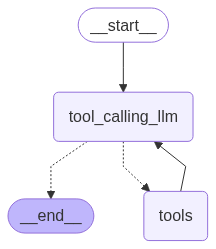

In [88]:
## StateGraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

##Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
                              tools_condition
                              )
builder.add_edge("tools","tool_calling_llm")

## Compile the graph

graph=builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [89]:
response = graph.invoke({"messages":"What is the recent AI news and find 5 multiply by 2"})

In [92]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and find 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8nr80whts)
 Call ID: 8nr80whts
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.computerworld.com/article/4035190/genai-tools-are-acting-more-alive-than-ever-they-blackmail-people-replicate-and-escape.html", "title": "GenAI self-preserves by blackmailing people, replicating itself, and escaping - Computerworld", "score": 0.8018276, "published_date": "Mon, 11 Aug 2025 10:04:38 GMT", "content": "news analysis ### OpenAI drops GPT-5: smarter, sharper, and built for the real world Aug 7, 2025 6 mins\n   n

In [91]:
response

{'messages': [HumanMessage(content='What is the recent AI news and find 5 multiply by 2', additional_kwargs={}, response_metadata={}, id='c539d8b3-8af8-46eb-8fbf-29e13b00103e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8nr80whts', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 4542, 'total_tokens': 4675, 'completion_time': 0.133954771, 'prompt_time': 0.785052994, 'queue_time': 0.342302997, 'total_time': 0.919007765}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0f1ab782-c4a7-4669-91e1-0c055282eb28-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth': 'advanced', 'topic': 'news'}, 'id': '8nr80whts', 'type': 'tool_call'}], usage_metadata=